eid data source: https://www.pxweb.bfs.admin.ch/pxweb/fr/px-x-1703030000_100/-/px-x-1703030000_100.px/table/tableViewLayout2/ $\newline$
2025 population data source: https://www.pxweb.bfs.admin.ch/pxweb/fr/px-x-0102020000_202/-/px-x-0102020000_202.px/
$\newline$
NDG data source: https://www.fedlex.admin.ch/eli/fga/2016/134/de
$\newline$
Note: this data analysis was done without any help from AI.


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import statsmodels.formula.api as smf

In [2]:
cantons_df = pd.read_csv("cantons_data.csv")
eid_df = pd.read_csv("eid_votation.csv")
ndg_df = pd.read_csv("NDG_data.csv")
old_eid_df = pd.read_csv("old_eid.csv")
matu_titre = pd.read_csv("matu_titres.csv")
ndg_votation_df = pd.read_csv("ndg_votation.csv")

In [3]:
cantons_df = cantons_df[cantons_df["Sex"] != "Sexe - total"]
cantons_df = cantons_df[cantons_df["Age"] != "100 ans ou plus"]
cantons_df = cantons_df[cantons_df["Canton"] != "Suisse"]
cantons_df = cantons_df[cantons_df["Canton"] != "Sans indication"]
col = ["Canton", "Age", "Sex", "Count", "Immigration", "Swiss citizenship acquisition"]
cantons_df = cantons_df[col]

cantons_df.head()

,Canton,Age,Sex,Count,Immigration,Swiss citizenship acquisition
332,Z�rich,18 ans,Homme,6227,29,106
333,Z�rich,19 ans,Homme,5993,34,74
334,Z�rich,20 ans,Homme,6065,39,63
335,Z�rich,21 ans,Homme,5925,32,42
336,Z�rich,22 ans,Homme,5819,38,28


In [4]:
cantons_df["Canton"].unique()

array(['Z�rich', 'Bern / Berne', 'Luzern', 'Uri', 'Schwyz', 'Obwalden',
       'Nidwalden', 'Glarus', 'Zug', 'Fribourg / Freiburg', 'Solothurn',
       'Basel-Stadt', 'Basel-Landschaft', 'Schaffhausen',
       'Appenzell Ausserrhoden', 'Appenzell Innerrhoden', 'St. Gallen',
       'Graub�nden / Grigioni / Grischun', 'Aargau', 'Thurgau', 'Ticino',
       'Vaud', 'Valais / Wallis', 'Neuch�tel', 'Gen�ve', 'Jura'],
      dtype=object)

In [5]:
def fix_cantons(cantons_df):
    cantons_df = cantons_df.replace('Z�rich','Zurich')
    cantons_df = cantons_df.replace('Bern / Berne','Berne')
    cantons_df = cantons_df.replace('Fribourg / Freiburg','Fribourg')
    cantons_df = cantons_df.replace('Graub�nden / Grigioni / Grischun','Grischun')
    cantons_df = cantons_df.replace('Valais / Wallis','Valais')
    cantons_df = cantons_df.replace('Neuch�tel','Neuchatel')
    cantons_df = cantons_df.replace('Gen�ve','Geneve')

    return cantons_df

cantons_df = fix_cantons(cantons_df)
eid_df = fix_cantons(eid_df)
old_eid_df = fix_cantons(old_eid_df)
ndg_votation_df = fix_cantons(ndg_votation_df)
matu_titre = fix_cantons(matu_titre)


In [6]:
cantons_df["Canton"].unique()

array(['Zurich', 'Berne', 'Luzern', 'Uri', 'Schwyz', 'Obwalden',
       'Nidwalden', 'Glarus', 'Zug', 'Fribourg', 'Solothurn',
       'Basel-Stadt', 'Basel-Landschaft', 'Schaffhausen',
       'Appenzell Ausserrhoden', 'Appenzell Innerrhoden', 'St. Gallen',
       'Grischun', 'Aargau', 'Thurgau', 'Ticino', 'Vaud', 'Valais',
       'Neuchatel', 'Geneve', 'Jura'], dtype=object)

In [7]:
cantons_population_df = cantons_df[["Canton", "Count"]].groupby(["Canton"]).sum()
cantons_population_df.head()

,Count
Canton,
Aargau,439719
Appenzell Ausserrhoden,37926
Appenzell Innerrhoden,11981
Basel-Landschaft,189200
Basel-Stadt,104868


In [8]:
eid_df.head()

,Canton,Voter registrations,Vote count,Participation %,Valid votes,Yes,No,yes_percentage
0,Suisse,5641040,2796897,49.58,2747948,1384586,1363362,50.39
1,Zurich,976490,509297,52.16,503923,274702,229221,54.51
2,Berne,750745,358855,47.80,354158,171771,182387,48.50
3,Luzern,288363,153604,53.27,151603,80261,71342,52.94
4,Uri,27226,12731,46.76,12567,5109,7458,40.65


In [9]:
cantons_df.head()

,Canton,Age,Sex,Count,Immigration,Swiss citizenship acquisition
332,Zurich,18 ans,Homme,6227,29,106
333,Zurich,19 ans,Homme,5993,34,74
334,Zurich,20 ans,Homme,6065,39,63
335,Zurich,21 ans,Homme,5925,32,42
336,Zurich,22 ans,Homme,5819,38,28


In [10]:
old_eid_df.head()

,Canton,Electeurs inscrits,Oui,Non,Oui en %
0,Suisse,5496858,984574,1778196,35.64
1,Zurich,952826,171915,314009,35.38
2,Berne,742146,120105,241218,33.24
3,Luzern,281263,56226,85710,39.61
4,Uri,26873,4147,7303,36.22


In [11]:
# for later graphs that have to do with age groups

age_groups = [range(18, 24), range(24,30), range(30, 36), range(36, 42), range(42, 48), range(48, 54), range(54, 60), range(60, 66),
              range(66, 72), range(72, 78), range(78, 84), range(84, 90), range(90, 96)]
def age_sort(df, age_groups):
    for i in range(95, 100):
        df = df[df["Age"] != str(i) + " ans"]
    # group by ages to count population groups
    for age_group in age_groups:
        new_string = str(age_group[0]) + " - " + str(age_group[-1])
        for age in age_group:
            age_string = str(age) + " ans"
            df = df.replace(age_string, new_string)
    df.reset_index()
    return df
        

In [12]:
def age_transform(df):
    for i in range(18, 100):
        age_string = str(i) + " ans"
        df = df.replace(age_string, i)
    return df

In [13]:
# represent demographics with percentages instead of count
def canton_proportions(df):
    df["Count"] = df["Count"] / df.groupby("Canton")["Count"].transform('sum')
    return df

In [14]:
cantons_df = canton_proportions(cantons_df)
cantons_df = cantons_df.rename(columns={"Count":"Proportion"})
cantons_df = cantons_df.replace("Homme","Male")
cantons_df = cantons_df.replace("Femme","Female")
cantons_df.head()

,Canton,Age,Sex,Proportion,Immigration,Swiss citizenship acquisition
332,Zurich,18 ans,Male,0.006559,29,106
333,Zurich,19 ans,Male,0.006313,34,74
334,Zurich,20 ans,Male,0.006389,39,63
335,Zurich,21 ans,Male,0.006241,32,42
336,Zurich,22 ans,Male,0.006129,38,28


In [15]:
#cantons_df = age_sort(cantons_df, age_groups)
cantons_df = age_transform(cantons_df)
cantons_df = cantons_df.groupby(["Canton", "Age", "Sex"]).sum()
cantons_df.head(10)

/var/folders/22/_dymvqsd4tgfb0zzj_kpnj340000gn/T/ipykernel_3125/749895442.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(age_string, i)


Proportion  Immigration  Swiss citizenship acquisition
Canton Age Sex                                                           
Aargau 18  Female    0.005881            4                             27
           Male      0.006156           11                             33
       19  Female    0.005886            9                             26
           Male      0.006318           11                             30
       20  Female    0.005799           10                             19
           Male      0.006334            2                             18
       21  Female    0.005981            8                             16
           Male      0.006297           12                             18
       22  Female    0.005831           10                             22
           Male      0.006274            7                             15

In [16]:
cantons_df = cantons_df.reset_index()
#cantons_df.pivot(columns=["Age", "Sex"], index="Canton", values=["Proportion"])
cantons_df.head()

,Canton,Age,Sex,Proportion,Immigration,Swiss citizenship acquisition
0,Aargau,18,Female,0.005881,4,27
1,Aargau,18,Male,0.006156,11,33
2,Aargau,19,Female,0.005886,9,26
3,Aargau,19,Male,0.006318,11,30
4,Aargau,20,Female,0.005799,10,19


In [17]:
cantons_df["Age_avg"] = cantons_df["Proportion"] * cantons_df["Age"]
ols_cantons = pd.DataFrame()
ols_cantons["Age_avg"] = cantons_df.groupby(["Canton"])["Age_avg"].sum()
ols_cantons["Immigration"] = cantons_df.groupby(["Canton"])["Immigration"].sum()
ols_cantons["swiss_citizenship_acquisition"] = cantons_df.groupby(["Canton"])["Swiss citizenship acquisition"].sum()

In [18]:
eid_df = eid_df.groupby(["Canton"]).sum()
eid_df.head(10)

,Voter registrations,Vote count,Participation %,Valid votes,Yes,No,yes_percentage
Canton,,,,,,,
Aargau,447798,232292,51.87,230470,113121,117349,49.08
Appenzell Ausserrhoden,39526,21896,55.40,21652,9949,11703,45.95
Appenzell Innerrhoden,12385,6006,48.49,5859,2644,3215,45.13
Basel-Landschaft,192244,96303,50.09,93940,46245,47695,49.23
Basel-Stadt,114378,55409,48.44,54544,30976,23568,56.79
Berne,750745,358855,47.80,354158,171771,182387,48.50
Fribourg,219163,100846,46.01,98853,49792,49061,50.37
Geneve,285837,119086,41.66,112906,62308,50598,55.19
Glarus,26836,12159,45.31,12008,4965,7043,41.35


In [19]:
old_eid_df = old_eid_df.groupby(["Canton"]).sum()
old_eid_df.head()

,Electeurs inscrits,Oui,Non,Oui en %
Canton,,,,
Aargau,434162,78468,129827,37.67
Appenzell Ausserrhoden,38972,7090,12474,36.24
Appenzell Innerrhoden,12149,2094,3284,38.94
Basel-Landschaft,189799,30328,60185,33.51
Basel-Stadt,114209,17998,43417,29.31


In [20]:
data_df = pd.merge(left=eid_df, right=ols_cantons, left_on="Canton", right_on="Canton", how="inner")
data_df

,Voter registrations,Vote count,Participation %,Valid votes,Yes,No,yes_percentage,Age_avg,Immigration,swiss_citizenship_acquisition
Canton,,,,,,,,,,
Aargau,447798,232292,51.87,230470,113121,117349,49.08,52.583427,925,2157
Appenzell Ausserrhoden,39526,21896,55.40,21652,9949,11703,45.95,53.506565,114,93
Appenzell Innerrhoden,12385,6006,48.49,5859,2644,3215,45.13,52.388031,17,21
Basel-Landschaft,192244,96303,50.09,93940,46245,47695,49.23,54.861559,520,947
Basel-Stadt,114378,55409,48.44,54544,30976,23568,56.79,53.480070,555,1023
Berne,750745,358855,47.80,354158,171771,182387,48.50,53.538567,1817,2366
Fribourg,219163,100846,46.01,98853,49792,49061,50.37,51.279168,528,565
Geneve,285837,119086,41.66,112906,62308,50598,55.19,51.223613,2465,2132
Glarus,26836,12159,45.31,12008,4965,7043,41.35,53.957518,64,78


In [21]:
a1 = sorted(ndg_df["Canton"].unique().tolist())
a2 = sorted(ndg_df["Canton"].unique().tolist())
a1 == a2

True

In [22]:
data_df = data_df.reset_index()

In [23]:
cantons_df["Canton"].unique()

array(['Aargau', 'Appenzell Ausserrhoden', 'Appenzell Innerrhoden',
       'Basel-Landschaft', 'Basel-Stadt', 'Berne', 'Fribourg', 'Geneve',
       'Glarus', 'Grischun', 'Jura', 'Luzern', 'Neuchatel', 'Nidwalden',
       'Obwalden', 'Schaffhausen', 'Schwyz', 'Solothurn', 'St. Gallen',
       'Thurgau', 'Ticino', 'Uri', 'Valais', 'Vaud', 'Zug', 'Zurich'],
      dtype=object)

In [24]:
# add language, 0 is French, 1 German, 2 French and German, 3 Italian
cantons_lang = {
    "Aargau": "German",
    "Appenzell Ausserrhoden": "German",
    "Appenzell Innerrhoden": "German",
    "Basel-Landschaft": "German",
    "Basel-Stadt": "German",
    "Berne": "Bilingual",
    "Fribourg": "Bilingual", 
    "Geneve": "French",
    "Glarus": "German",
    "Grischun": "Bilingual",
    "Jura": "French",
    "Luzern": "German",
    "Neuchatel": "French",
    "Nidwalden": "German",
    "Obwalden": "German",
    "Schaffhausen": "German",
    "Schwyz": "German",
    "Solothurn": "German",
    "St. Gallen": "German",
    "Thurgau": "German",
    "Ticino": "Italian",
    "Uri": "German",
    "Valais": "Bilingual",
    "Vaud": "French",
    "Zug": "German",
    "Zurich": "German"
}
data_df["Language"] = data_df["Canton"].map(lambda x: cantons_lang[x])

In [25]:
#https://en.wikipedia.org/wiki/List_of_Swiss_cantons_by_GRDP
cantons_gdp = {
    "Aargau": 67224,
    "Appenzell Ausserrhoden": 67341,
    "Appenzell Innerrhoden": 75526,
    "Basel-Landschaft": 77693,
    "Basel-Stadt": 209782,
    "Berne": 85151,
    "Fribourg": 64502, 
    "Geneve": 119644,
    "Glarus": 75430,
    "Grischun": 82817,
    "Jura": 78546,
    "Luzern": 75544,
    "Neuchatel": 106165,
    "Nidwalden": 74952,
    "Obwalden": 74902,
    "Schaffhausen": 100959,
    "Schwyz": 70739,
    "Solothurn": 73803,
    "St. Gallen": 85320,
    "Thurgau": 70504,
    "Ticino": 102190,
    "Uri": 58392,
    "Valais": 61387,
    "Vaud": 78021,
    "Zug": 192958,
    "Zurich": 104620
}
data_df["gdp_per_capita"] = data_df["Canton"].map(lambda x: cantons_gdp[x])

In [26]:
#https://www.geo-ref.net/ph/che.htm
density = {
    "Aargau": 528,
    "Appenzell Ausserrhoden": 234,
    "Appenzell Innerrhoden": 96,
    "Basel-Landschaft": 581,
    "Basel-Stadt": 5441,
    "Berne": 183,
    "Fribourg": 217, 
    "Geneve": 1883,
    "Glarus": 62,
    "Grischun": 29,
    "Jura": 89,
    "Luzern": 306,
    "Neuchatel": 223,
    "Nidwalden": 164,
    "Obwalden": 81,
    "Schaffhausen": 296,
    "Schwyz": 198,
    "Solothurn": 366,
    "St. Gallen": 276,
    "Thurgau": 131,
    "Ticino": 347,
    "Uri": 35,
    "Valais": 71,
    "Vaud": 303,
    "Zug": 559,
    "Zurich": 974
}
data_df["population_density"] = data_df["Canton"].map(lambda x: density[x])

In [27]:
model = smf.ols(formula='yes_percentage ~ Age_avg + C(Language) + Immigration + gdp_per_capita + population_density', data=data_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         yes_percentage   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     6.623
Date:                Tue, 05 May 2026   Prob (F-statistic):           0.000576
Time:                        10:44:03   Log-Likelihood:                -60.966
No. Observations:                  26   AIC:                             137.9
Df Residuals:                      18   BIC:                             148.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 90

t statistic over 3 is considered significant. 


In [28]:
data_df.head()

,Canton,Voter registrations,Vote count,Participation %,Valid votes,Yes,No,yes_percentage,Age_avg,Immigration,swiss_citizenship_acquisition,Language,gdp_per_capita,population_density
0,Aargau,447798,232292,51.87,230470,113121,117349,49.08,52.583427,925,2157,German,67224,528
1,Appenzell Ausserrhoden,39526,21896,55.40,21652,9949,11703,45.95,53.506565,114,93,German,67341,234
2,Appenzell Innerrhoden,12385,6006,48.49,5859,2644,3215,45.13,52.388031,17,21,German,75526,96
3,Basel-Landschaft,192244,96303,50.09,93940,46245,47695,49.23,54.861559,520,947,German,77693,581
4,Basel-Stadt,114378,55409,48.44,54544,30976,23568,56.79,53.480070,555,1023,German,209782,5441


In [29]:
cantons_df_ = data_df[["Canton", "Age_avg", "Immigration", "Language", "swiss_citizenship_acquisition", "gdp_per_capita", "population_density"]]
ndg_df = pd.merge(left=ndg_df, right=cantons_population_df, left_on="Canton", right_on="Canton", how="inner")

In [30]:
data_df.head()

,Canton,Voter registrations,Vote count,Participation %,Valid votes,Yes,No,yes_percentage,Age_avg,Immigration,swiss_citizenship_acquisition,Language,gdp_per_capita,population_density
0,Aargau,447798,232292,51.87,230470,113121,117349,49.08,52.583427,925,2157,German,67224,528
1,Appenzell Ausserrhoden,39526,21896,55.40,21652,9949,11703,45.95,53.506565,114,93,German,67341,234
2,Appenzell Innerrhoden,12385,6006,48.49,5859,2644,3215,45.13,52.388031,17,21,German,75526,96
3,Basel-Landschaft,192244,96303,50.09,93940,46245,47695,49.23,54.861559,520,947,German,77693,581
4,Basel-Stadt,114378,55409,48.44,54544,30976,23568,56.79,53.480070,555,1023,German,209782,5441


In [31]:
cantons_df_.head()

,Canton,Age_avg,Immigration,Language,swiss_citizenship_acquisition,gdp_per_capita,population_density
0,Aargau,52.583427,925,German,2157,67224,528
1,Appenzell Ausserrhoden,53.506565,114,German,93,67341,234
2,Appenzell Innerrhoden,52.388031,17,German,21,75526,96
3,Basel-Landschaft,54.861559,520,German,947,77693,581
4,Basel-Stadt,53.480070,555,German,1023,209782,5441


In [32]:
ndg_df = pd.merge(left=ndg_df, right=cantons_df_, left_on="Canton", right_on="Canton", how="inner")
old_eid_df = pd.merge(left=old_eid_df, right=cantons_df_, left_on="Canton", right_on="Canton", how="inner")
ndg_votation_df = pd.merge(left=ndg_votation_df, right=cantons_df_, left_on="Canton", right_on="Canton", how="inner")

In [33]:
ndg_df["Signatures"] = (ndg_df["Signatures"] * 10**3)/ndg_df["Count"]

In [34]:
ndg_df.head()

,Canton,Signatures,Count,Age_avg,Immigration,Language,swiss_citizenship_acquisition,gdp_per_capita,population_density
0,Zurich,14.630041,949348,51.748447,3387,German,7585,104620,974
1,Berne,15.313103,733816,53.538567,1817,Bilingual,2366,85151,183
2,Luzern,7.924254,284317,51.912235,575,German,982,75544,306
3,Uri,7.106637,27017,53.246437,43,German,43,58392,35
4,Schwyz,4.314232,107551,52.883302,250,German,407,70739,198


In [37]:
model = smf.ols(formula='Signatures ~ Age_avg + Immigration + Count + swiss_citizenship_acquisition + gdp_per_capita + + C(Language) + population_density', data=ndg_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Signatures   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     11.51
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.93e-05
Time:                        10:44:17   Log-Likelihood:                -61.180
No. Observations:                  26   AIC:                             142.4
Df Residuals:                      16   BIC:                             154.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [38]:
top_5_eid = data_df.sort_values(by=["yes_percentage"], ascending=False).head()

In [39]:
bottom_5_eid = data_df.sort_values(by=["yes_percentage"], ascending=True).head()

In [40]:
top_5_density = np.array(pd.to_numeric(top_5_eid['population_density']).astype('Int64'))
top_5_cantons = np.array(top_5_eid["Canton"])

[]

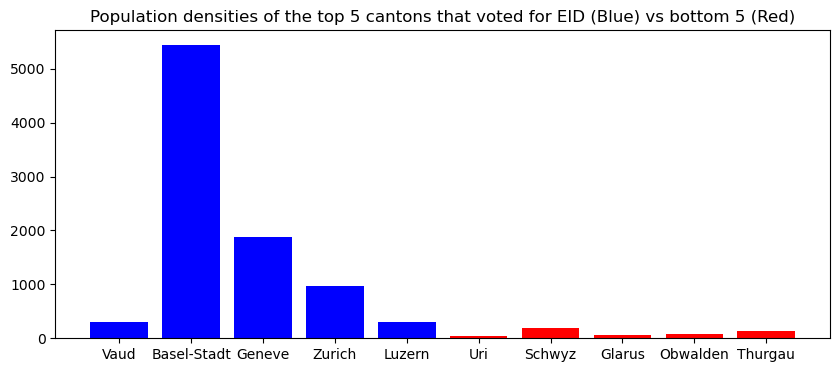

In [41]:
fig, ax = plt.subplots(figsize=(10,4))
plt.bar(top_5_cantons, top_5_density, color="b")
plt.bar(bottom_5_eid["Canton"], pd.to_numeric(bottom_5_eid['population_density']), color="r")
plt.title("Population densities of the top 5 cantons that voted for EID (Blue) vs bottom 5 (Red)")
plt.plot()

In [42]:
top_5_eid

,Canton,Voter registrations,Vote count,Participation %,Valid votes,Yes,No,yes_percentage,Age_avg,Immigration,swiss_citizenship_acquisition,Language,gdp_per_capita,population_density
23,Vaud,482162,218234,45.26,211784,121113,90671,57.19,51.376510,2636,3354,French,78021,303
4,Basel-Stadt,114378,55409,48.44,54544,30976,23568,56.79,53.480070,555,1023,German,209782,5441
7,Geneve,285837,119086,41.66,112906,62308,50598,55.19,51.223613,2465,2132,French,119644,1883
25,Zurich,976490,509297,52.16,503923,274702,229221,54.51,51.748447,3387,7585,German,104620,974
11,Luzern,288363,153604,53.27,151603,80261,71342,52.94,51.912235,575,982,German,75544,306


[]

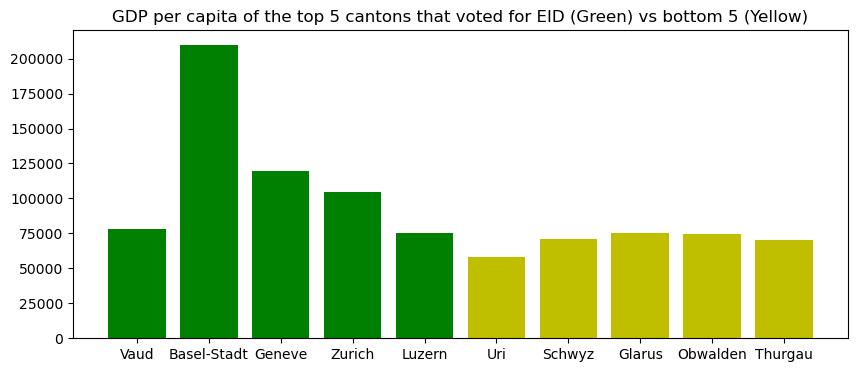

In [43]:
fig, ax = plt.subplots(figsize=(10,4))
plt.bar(top_5_eid["Canton"], top_5_eid["gdp_per_capita"], color="g")
plt.bar(bottom_5_eid["Canton"], pd.to_numeric(bottom_5_eid['gdp_per_capita']), color="y")
plt.title("GDP per capita of the top 5 cantons that voted for EID (Green) vs bottom 5 (Yellow)")
plt.plot()

[]

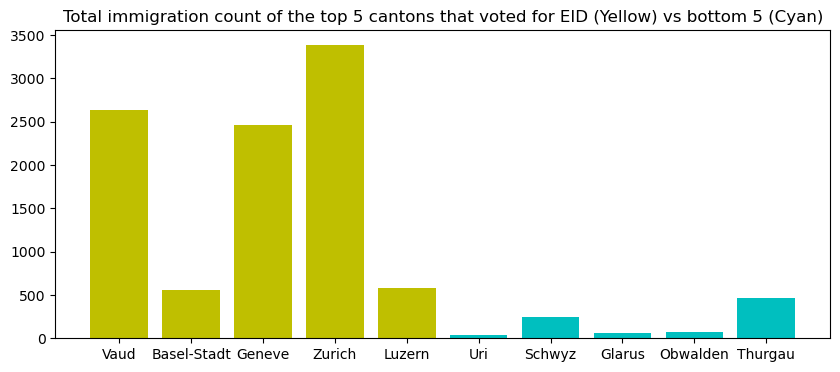

In [44]:
fig, ax = plt.subplots(figsize=(10,4))
plt.bar(top_5_eid["Canton"], top_5_eid["Immigration"], color="y")
plt.bar(bottom_5_eid["Canton"], pd.to_numeric(bottom_5_eid['Immigration']), color="c")
plt.title("Total immigration count of the top 5 cantons that voted for EID (Yellow) vs bottom 5 (Cyan)")
plt.plot()

In [45]:
data_df.loc[data_df["yes_percentage"] >= 50, "Accepted"] = "Yes"
data_df.loc[data_df["yes_percentage"] < 50, "Accepted"] = "No"
pie_df = data_df[["Accepted", "Language"]]
pie_2 = pie_df.groupby(["Language"]).value_counts()
pie_2 = pie_2.reset_index()

Text(0.5, 1.0, 'Pie chart of count of French speaking cantons for and against the EID law')

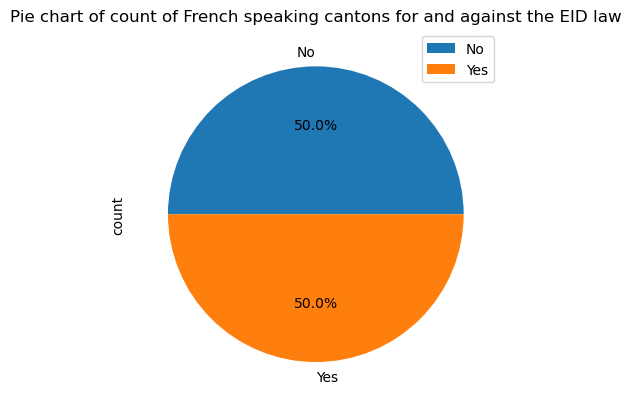

In [46]:
pie_french = pie_2[pie_2["Language"] == "French"].set_index("Accepted")
pie_french.plot.pie(y="count", autopct='%1.1f%%')
plt.title("Pie chart of count of French speaking cantons for and against the EID law")

Text(0.5, 1.0, 'Pie chart of count of German speaking cantons for and against the EID law')

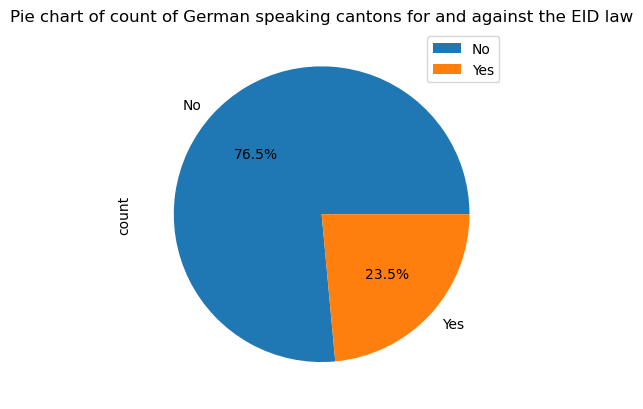

In [47]:
pie_german = pie_2[pie_2["Language"] == "German"].set_index("Accepted")
pie_german.plot.pie(y="count", autopct='%1.1f%%')
plt.title("Pie chart of count of German speaking cantons for and against the EID law")

Text(0.5, 1.0, 'Pie chart of count of Bilingual speaking cantons for and against the EID law')

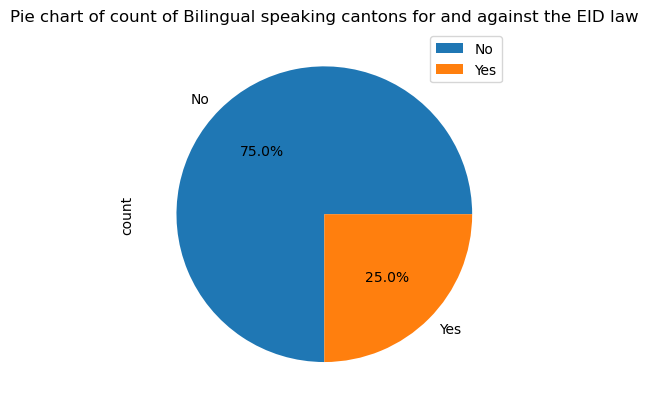

In [48]:
pie_bilingual = pie_2[pie_2["Language"] == "Bilingual"].set_index("Accepted")
pie_bilingual.plot.pie(y="count", autopct='%1.1f%%')
plt.title("Pie chart of count of Bilingual speaking cantons for and against the EID law")

In [49]:
#Note Signatures are per 100 inhabitants
bottom_5_ndg = ndg_df.sort_values(by="Signatures").head()
top_5_ndg = ndg_df.sort_values(by="Signatures", ascending=False).head()

In [50]:
old_eid_df.head()

,Canton,Electeurs inscrits,Oui,Non,Oui en %,Age_avg,Immigration,Language,swiss_citizenship_acquisition,gdp_per_capita,population_density
0,Aargau,434162,78468,129827,37.67,52.583427,925,German,2157,67224,528
1,Appenzell Ausserrhoden,38972,7090,12474,36.24,53.506565,114,German,93,67341,234
2,Appenzell Innerrhoden,12149,2094,3284,38.94,52.388031,17,German,21,75526,96
3,Basel-Landschaft,189799,30328,60185,33.51,54.861559,520,German,947,77693,581
4,Basel-Stadt,114209,17998,43417,29.31,53.480070,555,German,1023,209782,5441


[]

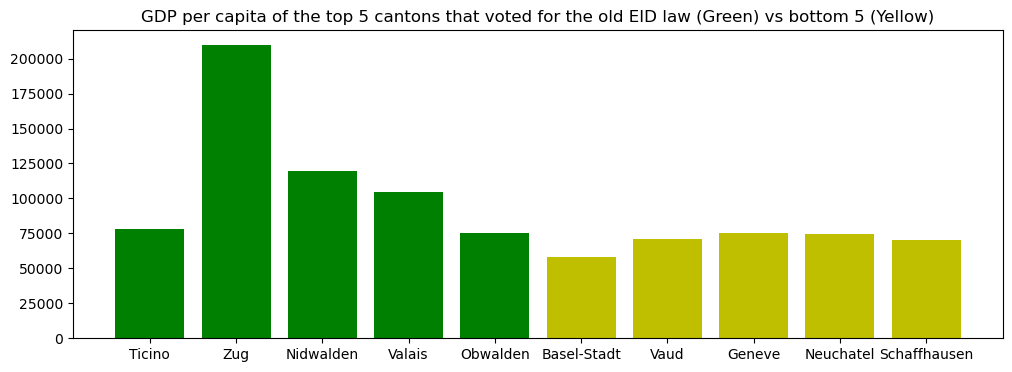

In [51]:
top_5_old_eid = old_eid_df.sort_values(by="Oui en %", ascending=False).head()
bottom_5_old_eid = old_eid_df.sort_values(by="Oui en %", ascending=True).head()
fig, ax = plt.subplots(figsize=(12,4))
plt.bar(top_5_old_eid["Canton"], top_5_eid["gdp_per_capita"], color="g")
plt.bar(bottom_5_old_eid["Canton"], pd.to_numeric(bottom_5_eid['gdp_per_capita']), color="y")
plt.title("GDP per capita of the top 5 cantons that voted for the old EID law (Green) vs bottom 5 (Yellow)")
plt.plot()

[]

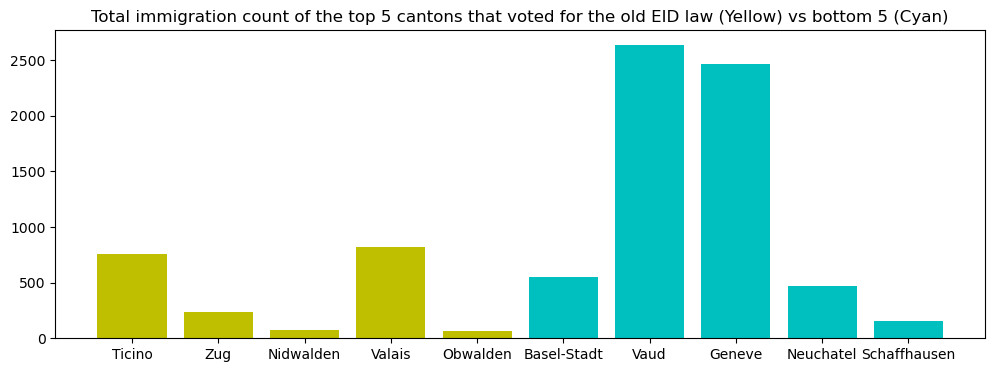

In [52]:
fig, ax = plt.subplots(figsize=(12,4))
plt.bar(top_5_old_eid["Canton"], top_5_old_eid["Immigration"], color="y")
plt.bar(bottom_5_old_eid["Canton"], pd.to_numeric(bottom_5_old_eid['Immigration']), color="c")
plt.title("Total immigration count of the top 5 cantons that voted for the old EID law (Yellow) vs bottom 5 (Cyan)")
plt.plot()

NDG analysis


[]

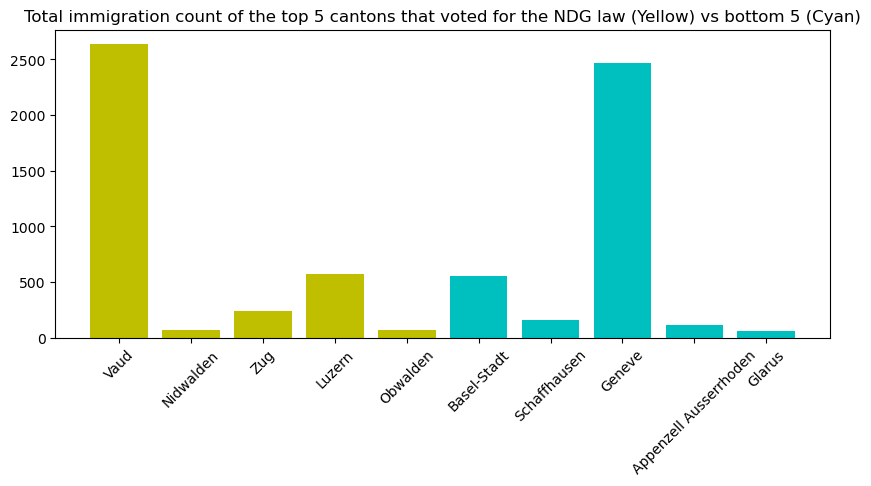

In [53]:
top_5_ndg_votation = ndg_votation_df.sort_values(by="yes_percentage", ascending=False).head()
bottom_5_ndg_votation = ndg_votation_df.sort_values(by="yes_percentage", ascending=True).head()
fig, ax = plt.subplots(figsize=(10,4))
ax.tick_params("x", rotation=45)
plt.bar(top_5_ndg_votation["Canton"], top_5_ndg_votation["Immigration"], color="y")
plt.bar(bottom_5_ndg_votation["Canton"], pd.to_numeric(bottom_5_ndg_votation['Immigration']), color="c")
plt.title("Total immigration count of the top 5 cantons that voted for the NDG law (Yellow) vs bottom 5 (Cyan)")
plt.plot()

[]

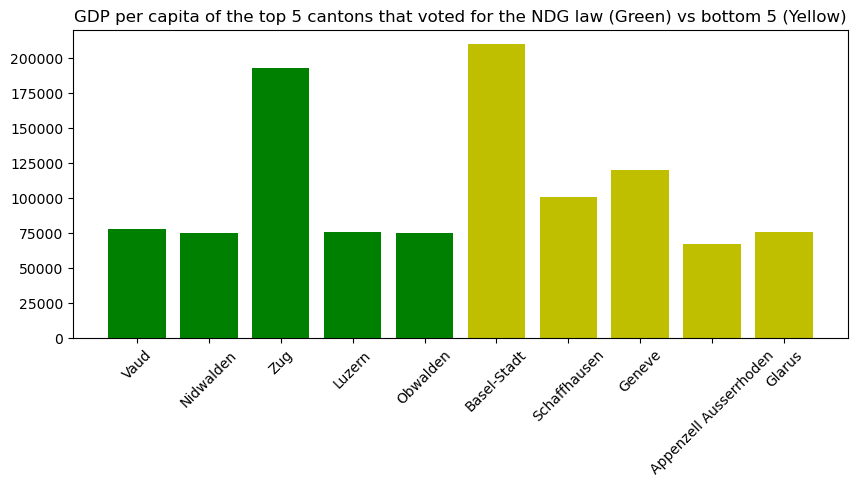

In [54]:
fig, ax = plt.subplots(figsize=(10,4))
ax.tick_params("x", rotation=45)
plt.bar(top_5_ndg_votation["Canton"], top_5_ndg_votation["gdp_per_capita"], color="g")
plt.bar(bottom_5_ndg_votation["Canton"], pd.to_numeric(bottom_5_ndg_votation['gdp_per_capita']), color="y")
plt.title("GDP per capita of the top 5 cantons that voted for the NDG law (Green) vs bottom 5 (Yellow)")
plt.plot()

In [55]:
model = smf.ols(formula='yes_percentage ~ Age_avg + Immigration + gdp_per_capita + population_density', data=ndg_votation_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         yes_percentage   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     5.616
Date:                Tue, 05 May 2026   Prob (F-statistic):            0.00310
Time:                        10:44:33   Log-Likelihood:                -60.889
No. Observations:                  26   AIC:                             131.8
Df Residuals:                      21   BIC:                             138.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            122.7639     34

[]

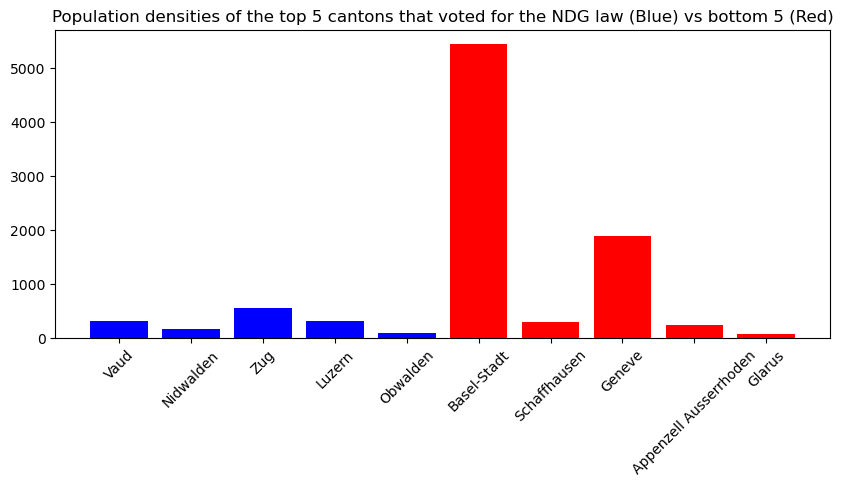

In [56]:
fig, ax = plt.subplots(figsize=(10,4))
ax.tick_params("x", rotation=45)
plt.bar(top_5_ndg_votation["Canton"], top_5_ndg_votation["population_density"], color="b")
plt.bar(bottom_5_ndg_votation["Canton"], bottom_5_ndg_votation["population_density"], color="r")
plt.title("Population densities of the top 5 cantons that voted for the NDG law (Blue) vs bottom 5 (Red)")
plt.plot()

In [57]:
ndg_votation_df.head()

,Canton,yes_percentage,Age_avg,Immigration,Language,swiss_citizenship_acquisition,gdp_per_capita,population_density
0,Zurich,63.98,51.748447,3387,German,7585,104620,974
1,Berne,65.91,53.538567,1817,Bilingual,2366,85151,183
2,Luzern,69.09,51.912235,575,German,982,75544,306
3,Uri,63.00,53.246437,43,German,43,58392,35
4,Schwyz,63.85,52.883302,250,German,407,70739,198


In [58]:
ndg_votation_df.loc[ndg_votation_df["yes_percentage"] >= 50, "Accepted"] = "Yes"
ndg_votation_df.loc[ndg_votation_df["yes_percentage"] < 50, "Accepted"] = "No"
ndg_pie_df = ndg_votation_df[["Accepted", "Language"]]
pie_2_ndg = ndg_pie_df.groupby(["Language"]).value_counts()
pie_2_ndg = pie_2_ndg.reset_index()

Text(0.5, 1.0, 'Pie chart of count of French speaking cantons for and against the EID law')

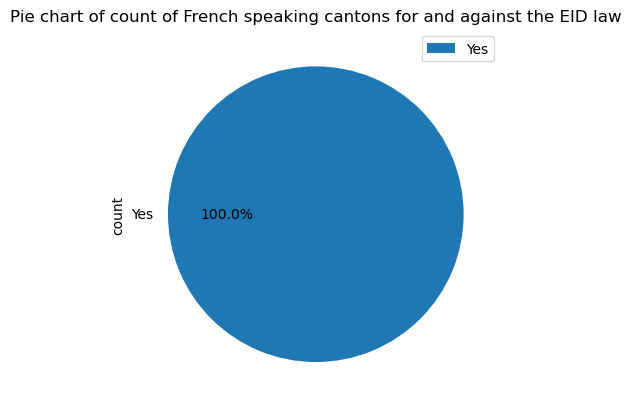

In [59]:
pie_french = pie_2_ndg[pie_2_ndg["Language"] == "French"].set_index("Accepted")
pie_french.plot.pie(y="count", autopct='%1.1f%%')
plt.title("Pie chart of count of French speaking cantons for and against the EID law")

Text(0.5, 1.0, 'Pie chart of count of German speaking cantons for and against the EID law')

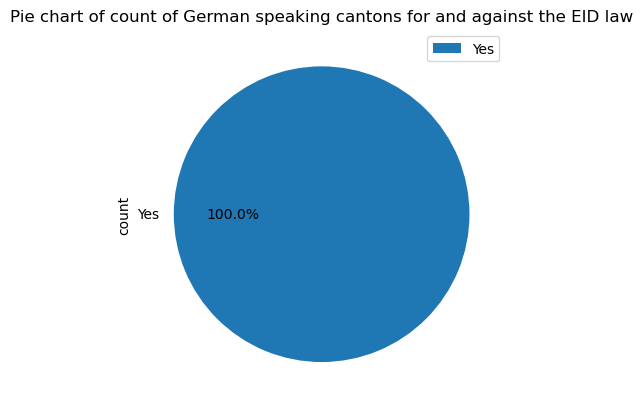

In [61]:
pie_german = pie_2_ndg[pie_2_ndg["Language"] == "German"].set_index("Accepted")
pie_german.plot.pie(y="count", autopct='%1.1f%%')
plt.title("Pie chart of count of German speaking cantons for and against the EID law")